'''LEVEL 1
TASK 1 · EDA on Retail Sales Data
Objective: Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.'''

'''1.Load dataset and perform initial inspection: shape, column dtypes, null value check'''

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [13]:
df=pd.read_csv("C:/Users/Ayush Singh/OIBSIB/L1-EDARetailSales.csv")
print(df.shape)
df.dtypes

(1000, 9)


Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

In [3]:
df.isnull()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False


In [4]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

'''2.Descriptive statistics: mean, median, mode, standard deviation for all numerical columns'''

In [5]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


'''3.Time series analysis: plot monthly and quarterly sales trends using line charts'''

In [6]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [7]:
df['Date']= pd.to_datetime(df['Date'])
df=df.set_index('Date') #after execution i relocate df value for new function

In [8]:
sns.set_theme(style="whitegrid")
monthly_sales= df.resample('ME')['Total Amount'].sum()
quarterly_sales= df.resample('QE')['Total Amount'].sum()
monthly_df= monthly_sales.reset_index()
quarterly_df= quarterly_sales.reset_index()

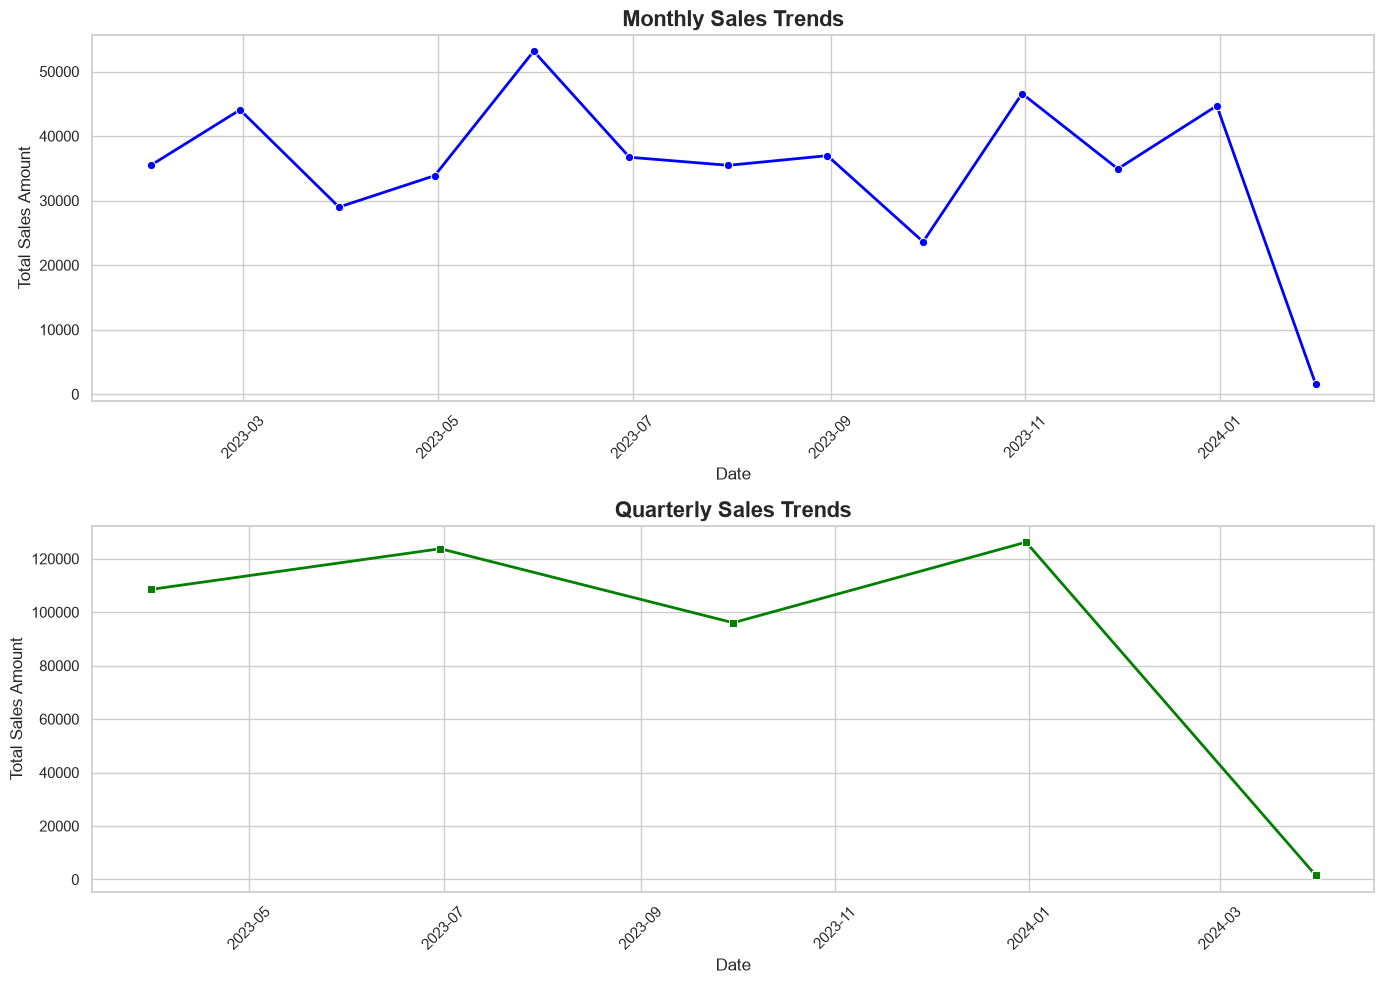

In [9]:
fig,(ax1,ax2)= plt.subplots(2,1,figsize=(14,10))
sns.lineplot(data=monthly_df,x='Date',y='Total Amount',ax=ax1,marker='o',linewidth=2,color='blue')
ax1.set_title('Monthly Sales Trends',fontsize=16,fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Sales Amount')
ax1.tick_params(axis='x',rotation=45)
sns.lineplot(data=quarterly_df,x='Date',y='Total Amount',ax=ax2,marker='s',linewidth=2,color='green')
ax2.set_title('Quarterly Sales Trends',fontsize=16,fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Total Sales Amount')
ax2.tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()

'''4.Customer demographics analysis: distribution of customer age groups, gender breakdown'''

Customer Demographics Analysis
Total Transactions: 1000

Gender Breakdown:
Gender
Female    510
Male      490
Name: count, dtype: int64
Percentage:
Gender
Female    51.0
Male      49.0
Name: count, dtype: float64%

Age Group Distribution:
Age Group
<18       21
19-30    252
31-45    303
46-60    331
60+       93
Name: count, dtype: int64
Percentage:
Age Group
<18       2.1
19-30    25.2
31-45    30.3
46-60    33.1
60+       9.3
Name: count, dtype: float64%

Average Spending by Gender:
Gender
Female    456.55
Male      455.43
Name: Total Amount, dtype: float64

Average Spending by Age Group:
Age Group
<18      534.05
19-30    483.06
31-45    468.50
46-60    446.75
60+      357.26
Name: Total Amount, dtype: float64

Top Product Category per Gender:
Gender
Female    Clothing
Male      Clothing
Name: Product Category, dtype: str


C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_27344\2445979667.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_count.index,y=gender_count.values,ax=axs[0, 0],palette='pastel')
C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_27344\2445979667.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_group_count.index,y=age_group_count.values,ax=axs[0, 1],palette='viridis')
C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_27344\2445979667.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_spend_gender.index,y=avg_s

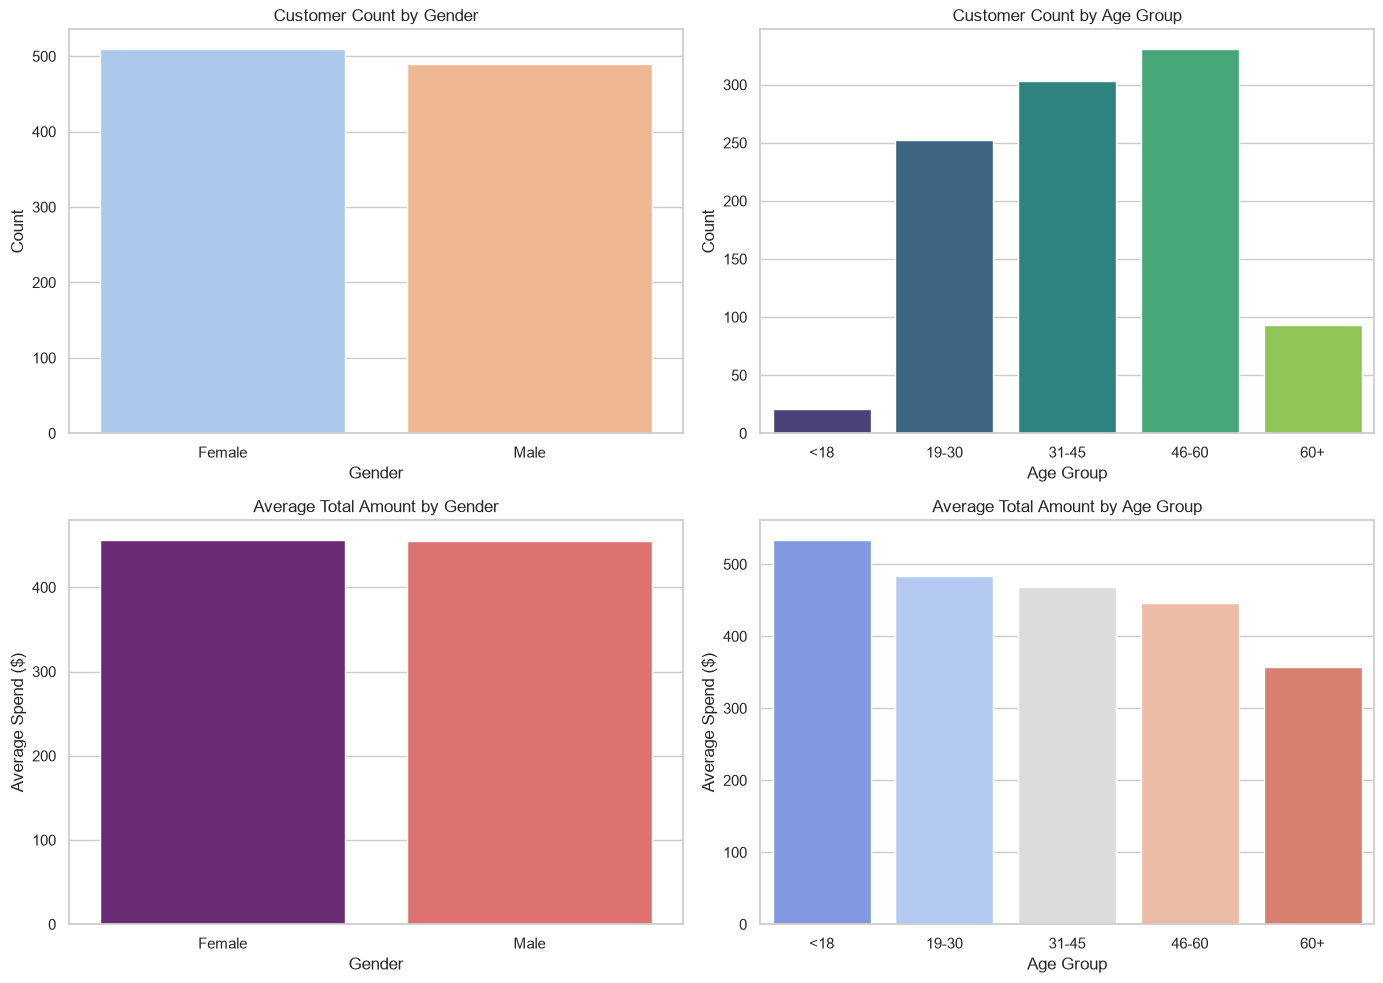

In [10]:
def analyze_customer_demographics(df, print_data=True):
    bins = [0,18,30,45,60,100]
    labels = ['<18','19-30','31-45','46-60','60+']
    df['Age Group'] = pd.cut(df['Age'],bins=bins,labels=labels,right=True)
    total_customers=len(df)
    gender_count =df['Gender'].value_counts()
    gender_pct =(gender_count / total_customers *100).round(1)
    age_group_count = df['Age Group'].value_counts().sort_index()
    age_group_pct =(age_group_count / total_customers*100).round(1)
    avg_spend_gender = df.groupby('Gender')['Total Amount'].mean().round(2)
    avg_spend_age = df.groupby('Age Group',observed=True)['Total Amount'].mean().round(2)
    top_cat_gender = df.groupby('Gender')['Product Category'].apply(
        lambda x: x.value_counts().idxmax()
    )
    if print_data:
        print("Customer Demographics Analysis")
        print(f"Total Transactions: {total_customers}\n")
        print("Gender Breakdown:")
        print(gender_count)
        print(f"Percentage:\n{gender_pct}%\n")
        print("Age Group Distribution:")
        print(age_group_count)
        print(f"Percentage:\n{age_group_pct}%\n")
        print("Average Spending by Gender:")
        print(avg_spend_gender)
        print("\nAverage Spending by Age Group:")
        print(avg_spend_age)
        print("\nTop Product Category per Gender:")
        print(top_cat_gender)
    fig, axs = plt.subplots(2,2,figsize=(14,10))
    sns.barplot(x=gender_count.index,y=gender_count.values,ax=axs[0, 0],palette='pastel')
    axs[0, 0].set_title('Customer Count by Gender')
    axs[0, 0].set_ylabel('Count')
    sns.barplot(x=age_group_count.index,y=age_group_count.values,ax=axs[0, 1],palette='viridis')
    axs[0, 1].set_title('Customer Count by Age Group')
    axs[0, 1].set_ylabel('Count')
    sns.barplot(x=avg_spend_gender.index,y=avg_spend_gender.values,ax=axs[1, 0],palette='magma')
    axs[1, 0].set_title('Average Total Amount by Gender')
    axs[1, 0].set_ylabel('Average Spend ($)')
    sns.barplot(x=avg_spend_age.index,y=avg_spend_age.values,ax=axs[1, 1],palette='coolwarm')
    axs[1, 1].set_title('Average Total Amount by Age Group')
    axs[1, 1].set_ylabel('Average Spend ($)')
    plt.tight_layout()
    plt.show()
    return {
        'gender_count': gender_count,
        'gender_percentage': gender_pct,
        'age_group_count': age_group_count,
        'age_group_percentage': age_group_pct,
        'avg_spend_gender': avg_spend_gender,
        'avg_spend_age': avg_spend_age,
        'top_category_gender': top_cat_gender
    }
demographics_report = analyze_customer_demographics(df)   

'''5.Product analysis: top 10 best-selling products; revenue by product category (bar chart)'''

C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_27344\4110451516.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_category.index, y=revenue_by_category.values, palette='viridis', ax=ax)


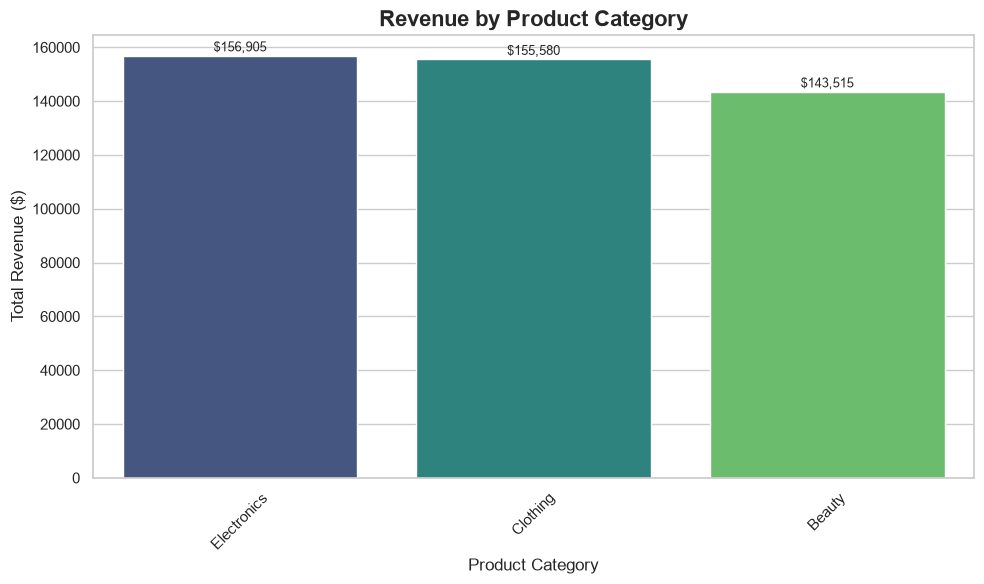

Top 10 Best-Selling Product Categories:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


In [11]:
top_10_products = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).head(10)
revenue_by_category = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=revenue_by_category.index, y=revenue_by_category.values, palette='viridis', ax=ax)
ax.set_title('Revenue by Product Category',fontsize=16,fontweight='bold')
ax.set_xlabel('Product Category',fontsize=12)
ax.set_ylabel('Total Revenue ($)',fontsize=12)
ax.tick_params(axis='x',rotation=45)
for i, v in enumerate(revenue_by_category.values):
    ax.text(i,v+max(revenue_by_category.values)*0.01,f"${v:,.0f}",ha='center',fontsize=9)
plt.tight_layout()
plt.show()
print("Top 10 Best-Selling Product Categories:")
print(top_10_products)

'''6.Heatmap: correlation matrix between numerical variables'''

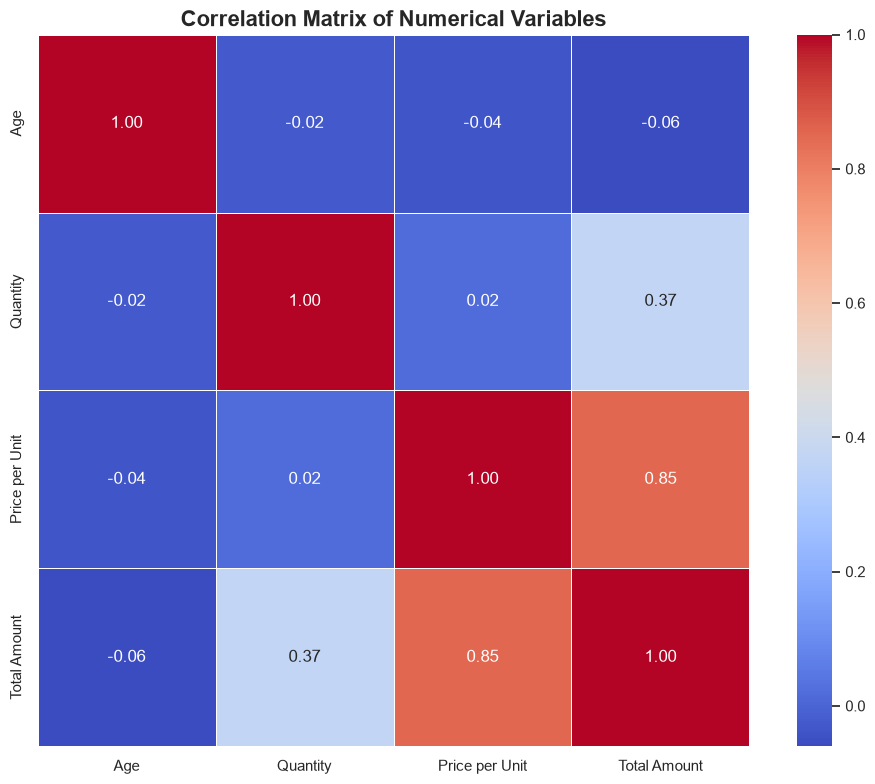

Correlation Matrix:
                      Age  Quantity  Price per Unit  Total Amount
Age             1.000000 -0.023737       -0.038423     -0.060568
Quantity       -0.023737  1.000000        0.017501      0.373707
Price per Unit -0.038423  0.017501        1.000000      0.851925
Total Amount   -0.060568  0.373707        0.851925      1.000000


In [12]:
numerical_df=df.select_dtypes(include=['float64','int64'])
if 'Transaction ID' in numerical_df.columns:
    numerical_df= numerical_df.drop(columns=['Transaction ID'])
corr_matrix= numerical_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()
print("Correlation Matrix:\n", corr_matrix)   

'''7.At least one additional visualisation of your choice that reveals a non-obvious insight(A week-daywise analysis)'''

C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_27344\3364689361.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_sales, x='Day of Week', y='Total Amount', order=day_order, palette='coolwarm', errorbar=None)


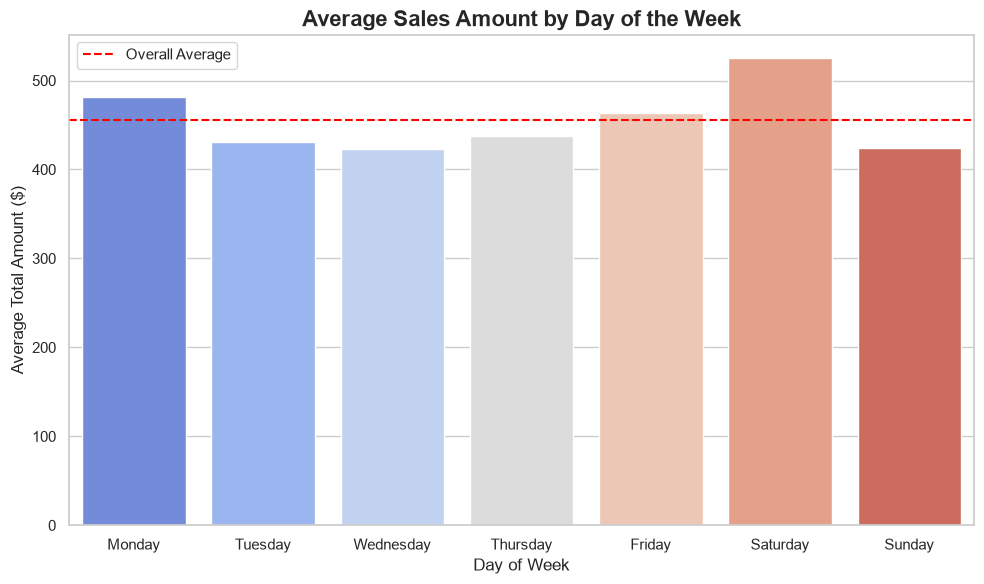

Best performing day: Saturday with an average sale of $525.43


In [14]:
#re-run df codeline to assign it datset as it is standlone feature which works with datset but here to obtain previous outcomes Date column got trimmed
df['Date'] = pd.to_datetime(df['Date'])
df['Day of Week'] = df['Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_sales = df.groupby('Day of Week', observed=True)['Total Amount'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=daily_sales, x='Day of Week', y='Total Amount', order=day_order, palette='coolwarm', errorbar=None)
plt.title('Average Sales Amount by Day of the Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Total Amount ($)')
plt.axhline(y=daily_sales['Total Amount'].mean(), color='red', linestyle='--', label='Overall Average')
plt.legend()
plt.tight_layout()
plt.show()
best_day = daily_sales.loc[daily_sales['Total Amount'].idxmax()]
print(f"Best performing day: {best_day['Day of Week']} with an average sale of ${best_day['Total Amount']:.2f}")   